# House Price Prediction — 04: Model Tuning (Random Forest)

**Champion from `03_model_training.ipynb`:** Random Forest (default params) — RMSE: 0.4896, MAE: 0.3193, R²: 0.8182

**Goal:** Try 8 deliberately different tuning configurations, each testing a specific hypothesis about what might improve generalization, then pick the best one.

**Methodology note — why cross-validation instead of repeatedly checking the test set:**
Evaluating 8 variants directly against the test set (the way `03_model_training.ipynb` compared 6 different *model types* once each) risks a subtle problem here: since all 8 variants are the *same* model family, repeatedly peeking at test performance to pick a winner among them risks indirectly overfitting to the test set through model selection. Instead, each variant below is scored using **5-fold cross-validation on the training set only**. The winning configuration is then retrained on the full training set and evaluated **exactly once** on the held-out test set for a final, honest estimate.

**The 8 variants:**
1. Baseline (matches notebook 3's champion) — reference point
2. More trees — does averaging over more trees reduce variance?
3. Depth regularization — does limiting tree depth reduce overfitting?
4. Leaf-size regularization — does requiring more samples per leaf smooth out noise?
5. Stronger leaf + split regularization — pushing #4 further
6. Feature randomness — does limiting features-per-split decorrelate trees more?
7. Bootstrap subsampling — does limiting each tree's training sample increase useful diversity?
8. Systematic search (`RandomizedSearchCV`) — let the search find combinations manual guessing might miss

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style('whitegrid')
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Data

Random Forest uses the **tree feature set**: unscaled, raw `MedInc`/`Population` (no `log_*` columns — redundant for tree-based splitting).

In [2]:
def load_pkl(name):
    with open(f'outputs/{name}.pkl', 'rb') as f:
        return pickle.load(f)

X_train = load_pkl('X_train')
X_test = load_pkl('X_test')
y_train = load_pkl('y_train')
y_test = load_pkl('y_test')

log_cols = ['log_MedInc', 'log_Population']
X_train_tree = X_train.drop(columns=log_cols)
X_test_tree = X_test.drop(columns=log_cols)

print(f'Train: {X_train_tree.shape}, Test: {X_test_tree.shape}')
print(f'Columns: {list(X_train_tree.columns)}')

Train: (16428, 9), Test: (4107, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'is_max_house_age', 'bedroom_ratio']


## 3. Diagnose the Baseline: Is It Overfitting?

Before guessing which hyperparameters to tune, check whether the baseline model is actually overfitting (train score much better than test score) — this tells us whether regularization-style tuning (limiting depth, requiring more samples per leaf) is even the right direction to explore.

In [3]:
baseline = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
baseline.fit(X_train_tree, y_train)

train_pred = baseline.predict(X_train_tree)
test_pred = baseline.predict(X_test_tree)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print(f'Train RMSE: {train_rmse:.4f}')
print(f'Test RMSE:  {test_rmse:.4f}')
print(f'Gap: {test_rmse - train_rmse:.4f}')

Train RMSE: 0.1880
Test RMSE:  0.4896
Gap: 0.3016


**If train RMSE is much lower than test RMSE**, the default (unlimited depth) trees are likely memorizing the training data rather than learning generalizable patterns — this motivates variants 3-7 below, which each apply a different form of regularization. **If the gap is small**, regularization may not help much, and tuning should instead focus on giving the model more capacity (more trees, more splits) — this motivates variant 2.

## 4. Cross-Validation Helper

Manually implemented with `KFold` (rather than `cross_val_score`) so all three metrics — RMSE, MAE, R² — are computed in a single pass per fold, instead of running cross-validation three separate times.

In [5]:
def evaluate_cv(model, X, y, cv=5, random_state=42):
    kf = KFold(n_splits=cv, shuffle=True, random_state=random_state)
    rmse_scores, mae_scores, r2_scores = [], [], []

    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)
        preds = m.predict(X_val)

        rmse_scores.append(np.sqrt(mean_squared_error(y_val, preds)))
        mae_scores.append(mean_absolute_error(y_val, preds))
        r2_scores.append(r2_score(y_val, preds))

    return {
        'RMSE_mean': np.mean(rmse_scores), 'RMSE_std': np.std(rmse_scores),
        'MAE_mean': np.mean(mae_scores), 'MAE_std': np.std(mae_scores),
        'R2_mean': np.mean(r2_scores), 'R2_std': np.std(r2_scores),
    }

print('CV helper defined.')

CV helper defined.


## 5. Define & Evaluate 8 Variants

In [6]:
tuning_results = []

### V1 — Baseline
**Goal:** Reference point — same configuration as the champion selected in notebook 3. Every other variant is judged relative to this.

In [7]:
v1 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
scores = evaluate_cv(v1, X_train_tree, y_train)
scores['Variant'] = 'V1: Baseline'
scores['Params'] = 'n_estimators=100'
tuning_results.append(scores)
print(scores)

{'RMSE_mean': np.float64(0.5079946737010643), 'RMSE_std': np.float64(0.007112565623493639), 'MAE_mean': np.float64(0.3325023461813702), 'MAE_std': np.float64(0.004646290634281818), 'R2_mean': np.float64(0.806507861303418), 'R2_std': np.float64(0.008967314065809261), 'Variant': 'V1: Baseline', 'Params': 'n_estimators=100'}


### V2 — More Trees
**Goal:** Test whether averaging over more trees reduces prediction variance and stabilizes results. More trees rarely cause overfitting by themselves (each tree still sees a bootstrap sample), so this is a low-risk lever to test first.

In [8]:
v2 = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
scores = evaluate_cv(v2, X_train_tree, y_train)
scores['Variant'] = 'V2: More Trees'
scores['Params'] = 'n_estimators=300'
tuning_results.append(scores)
print(scores)

{'RMSE_mean': np.float64(0.5065013356002339), 'RMSE_std': np.float64(0.007350349745592374), 'MAE_mean': np.float64(0.33131126839003316), 'MAE_std': np.float64(0.004571947059039042), 'R2_mean': np.float64(0.8076340083852409), 'R2_std': np.float64(0.009159237447477531), 'Variant': 'V2: More Trees', 'Params': 'n_estimators=300'}


### V3 — Depth Regularization
**Goal:** By default, trees grow until leaves are pure (unlimited depth) — a classic overfitting risk. Capping `max_depth` forces each tree to stop splitting earlier, trading some training accuracy for better generalization.

In [9]:
v3 = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
scores = evaluate_cv(v3, X_train_tree, y_train)
scores['Variant'] = 'V3: Depth Regularization'
scores['Params'] = 'n_estimators=200, max_depth=10'
tuning_results.append(scores)
print(scores)

{'RMSE_mean': np.float64(0.5410065370989191), 'RMSE_std': np.float64(0.007310781707651172), 'MAE_mean': np.float64(0.3662339474192048), 'MAE_std': np.float64(0.004977800974733185), 'R2_mean': np.float64(0.7805689084528706), 'R2_std': np.float64(0.009475933663329918), 'Variant': 'V3: Depth Regularization', 'Params': 'n_estimators=200, max_depth=10'}


### V4 — Leaf-Size Regularization
**Goal:** `min_samples_leaf` forces every leaf to represent at least N training examples, preventing the tree from creating tiny leaves that fit individual noisy data points. This smooths predictions in a different way than capping depth.

In [10]:
v4 = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=42, n_jobs=-1)
scores = evaluate_cv(v4, X_train_tree, y_train)
scores['Variant'] = 'V4: Leaf-Size Regularization'
scores['Params'] = 'n_estimators=200, min_samples_leaf=5'
tuning_results.append(scores)
print(scores)

{'RMSE_mean': np.float64(0.5134397330493423), 'RMSE_std': np.float64(0.007140266548630779), 'MAE_mean': np.float64(0.33581914615570263), 'MAE_std': np.float64(0.004920259948009554), 'R2_mean': np.float64(0.8023493011681847), 'R2_std': np.float64(0.008857320322920926), 'Variant': 'V4: Leaf-Size Regularization', 'Params': 'n_estimators=200, min_samples_leaf=5'}


### V5 — Stronger Leaf + Split Regularization
**Goal:** Push V4 further — require even larger leaves (`min_samples_leaf=10`) and also raise `min_samples_split` (the minimum samples needed before a node is allowed to split at all). Tests whether stronger regularization helps more, or whether it starts to underfit.

In [11]:
v5 = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=10, min_samples_split=10,
    random_state=42, n_jobs=-1
)
scores = evaluate_cv(v5, X_train_tree, y_train)
scores['Variant'] = 'V5: Stronger Leaf+Split Regularization'
scores['Params'] = 'n_estimators=300, min_samples_leaf=10, min_samples_split=10'
tuning_results.append(scores)
print(scores)

{'RMSE_mean': np.float64(0.527866178879254), 'RMSE_std': np.float64(0.0065673309805519475), 'MAE_mean': np.float64(0.34798098213151507), 'MAE_std': np.float64(0.0049006753711287356), 'R2_mean': np.float64(0.7910986549414619), 'R2_std': np.float64(0.008918130022488494), 'Variant': 'V5: Stronger Leaf+Split Regularization', 'Params': 'n_estimators=300, min_samples_leaf=10, min_samples_split=10'}


### V6 — Feature Randomness
**Goal:** By default, each split considers all features. Limiting `max_features` (e.g. to `sqrt(n_features)`) forces each tree to consider a random subset of features per split, making individual trees more different from each other (less correlated), which can improve the ensemble's combined accuracy.

In [12]:
v6 = RandomForestRegressor(n_estimators=300, max_features='sqrt', random_state=42, n_jobs=-1)
scores = evaluate_cv(v6, X_train_tree, y_train)
scores['Variant'] = 'V6: Feature Randomness'
scores['Params'] = "n_estimators=300, max_features='sqrt'"
tuning_results.append(scores)
print(scores)

{'RMSE_mean': np.float64(0.4975639443256908), 'RMSE_std': np.float64(0.005968032512695424), 'MAE_mean': np.float64(0.3307715444622946), 'MAE_std': np.float64(0.002345314606932281), 'R2_mean': np.float64(0.8144549194099963), 'R2_std': np.float64(0.006278326698314275), 'Variant': 'V6: Feature Randomness', 'Params': "n_estimators=300, max_features='sqrt'"}


### V7 — Bootstrap Subsampling
**Goal:** By default, each tree bootstraps a sample roughly the size of the full training set. Limiting `max_samples` (e.g. to 70% of training rows per tree) increases diversity between trees in a different way than `max_features` — each tree sees a different slice of *rows* instead of a different slice of *columns*.

In [13]:
v7 = RandomForestRegressor(n_estimators=300, max_samples=0.7, random_state=42, n_jobs=-1)
scores = evaluate_cv(v7, X_train_tree, y_train)
scores['Variant'] = 'V7: Bootstrap Subsampling'
scores['Params'] = 'n_estimators=300, max_samples=0.7'
tuning_results.append(scores)
print(scores)

{'RMSE_mean': np.float64(0.5117330592851778), 'RMSE_std': np.float64(0.007444639713467251), 'MAE_mean': np.float64(0.33636892129939233), 'MAE_std': np.float64(0.004874689760413508), 'R2_mean': np.float64(0.8036553214385869), 'R2_std': np.float64(0.009003727343097635), 'Variant': 'V7: Bootstrap Subsampling', 'Params': 'n_estimators=300, max_samples=0.7'}


### V8 — Systematic Search (`RandomizedSearchCV`)
**Goal:** V1-V7 each tested one or two hyperparameters in isolation, based on guesses about what might help. `RandomizedSearchCV` instead samples many random *combinations* across all these levers at once, which can find interactions between hyperparameters that manual one-at-a-time testing would miss. The search space below is informed by the ranges explored in V1-V7.

This step does its own internal 5-fold CV — may take a few minutes depending on hardware.

In [14]:
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 10, 15, 20, 25],
    'min_samples_leaf': [1, 2, 5, 10],
    'min_samples_split': [2, 5, 10],
    'max_features': [1.0, 'sqrt', 'log2'],
    'max_samples': [None, 0.7, 0.8, 0.9],
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train_tree, y_train)

print(f'Best params found: {search.best_params_}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params found: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_samples': 0.8, 'max_features': 'log2', 'max_depth': None}


In [16]:
v8 = RandomForestRegressor(**search.best_params_, random_state=42, n_jobs=-1)
scores = evaluate_cv(v8, X_train_tree, y_train)
scores['Variant'] = 'V8: Systematic Search'
scores['Params'] = str(search.best_params_)
tuning_results.append(scores)
print(scores)

{'RMSE_mean': np.float64(0.5053047189161617), 'RMSE_std': np.float64(0.006609880691217789), 'MAE_mean': np.float64(0.33762620564732615), 'MAE_std': np.float64(0.002939239038268809), 'R2_mean': np.float64(0.8086195933585593), 'R2_std': np.float64(0.007086761842605539), 'Variant': 'V8: Systematic Search', 'Params': "{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_samples': 0.8, 'max_features': 'log2', 'max_depth': None}"}


## 6. Compare All 8 Variants (Cross-Validated Scores)

In [17]:
tuning_df = pd.DataFrame(tuning_results)
tuning_df = tuning_df[['Variant', 'Params', 'RMSE_mean', 'RMSE_std', 'MAE_mean', 'MAE_std', 'R2_mean', 'R2_std']]
tuning_df = tuning_df.sort_values('RMSE_mean').reset_index(drop=True)
tuning_df

,Variant,Params,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std
0,V6: Feature Randomness,"n_estimators=300, max_features='sqrt'",0.497564,0.005968,0.330772,0.002345,0.814455,0.006278
1,V8: Systematic Search,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.505305,0.006610,0.337626,0.002939,0.808620,0.007087
2,V8: Systematic Search,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.505305,0.006610,0.337626,0.002939,0.808620,0.007087
3,V2: More Trees,n_estimators=300,0.506501,0.007350,0.331311,0.004572,0.807634,0.009159
4,V1: Baseline,n_estimators=100,0.507995,0.007113,0.332502,0.004646,0.806508,0.008967
5,V7: Bootstrap Subsampling,"n_estimators=300, max_samples=0.7",0.511733,0.007445,0.336369,0.004875,0.803655,0.009004
6,V4: Leaf-Size Regularization,"n_estimators=200, min_samples_leaf=5",0.513440,0.007140,0.335819,0.004920,0.802349,0.008857
7,V5: Stronger Leaf+Split Regularization,"n_estimators=300, min_samples_leaf=10, min_sam...",0.527866,0.006567,0.347981,0.004901,0.791099,0.008918
8,V3: Depth Regularization,"n_estimators=200, max_depth=10",0.541007,0.007311,0.366234,0.004978,0.780569,0.009476


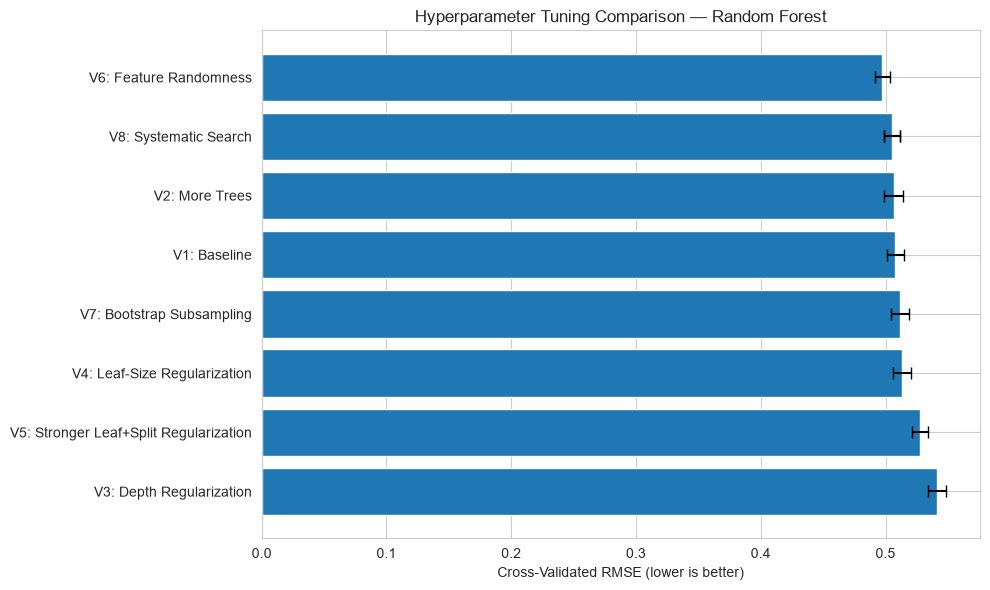

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_df = tuning_df.sort_values('RMSE_mean', ascending=True)
ax.barh(plot_df['Variant'], plot_df['RMSE_mean'], xerr=plot_df['RMSE_std'], capsize=4)
ax.set_xlabel('Cross-Validated RMSE (lower is better)')
ax.set_title('Hyperparameter Tuning Comparison — Random Forest')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/tuning_comparison.png', dpi=150)
plt.show()

## 7. Select Best Variant & Final Evaluation

This is the **only** point in this notebook where the test set gets touched — the winning variant (by cross-validated RMSE) is retrained on the full training set and evaluated once for a final, honest performance estimate.

In [19]:
best_variant_name = tuning_df.iloc[0]['Variant']
best_params_str = tuning_df.iloc[0]['Params']
print(f'Best variant (by CV RMSE): {best_variant_name}')
print(f'Params: {best_params_str}')

Best variant (by CV RMSE): V6: Feature Randomness
Params: n_estimators=300, max_features='sqrt'


In [20]:
# Map variant names back to their actual model objects for final retraining
variant_models = {
    'V1: Baseline': v1,
    'V2: More Trees': v2,
    'V3: Depth Regularization': v3,
    'V4: Leaf-Size Regularization': v4,
    'V5: Stronger Leaf+Split Regularization': v5,
    'V6: Feature Randomness': v6,
    'V7: Bootstrap Subsampling': v7,
    'V8: Systematic Search': v8,
}

final_model = clone(variant_models[best_variant_name])
final_model.fit(X_train_tree, y_train)
final_pred = final_model.predict(X_test_tree)

final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
final_mae = mean_absolute_error(y_test, final_pred)
final_r2 = r2_score(y_test, final_pred)

print(f'Final test performance — {best_variant_name}')
print(f'RMSE: {final_rmse:.4f} | MAE: {final_mae:.4f} | R2: {final_r2:.4f}')
print()
print('Compare to notebook 3 baseline champion (test set, default params):')
print('RMSE: 0.4896 | MAE: 0.3193 | R2: 0.8182')

Final test performance — V6: Feature Randomness
RMSE: 0.4744 | MAE: 0.3136 | R2: 0.8293

Compare to notebook 3 baseline champion (test set, default params):
RMSE: 0.4896 | MAE: 0.3193 | R2: 0.8182


**Interpretation:** if the tuned model's test RMSE is only marginally better (or even slightly worse) than the notebook 3 baseline, that's a meaningful and common finding — Random Forest is often fairly robust to hyperparameter choices on tabular data like this, and the default configuration may already have been close to optimal. A small, honest improvement is still worth reporting; an absent improvement is worth reporting too, since over-claiming gains that cross-validation didn't actually support would undermine the project's credibility.

## 8. Residual Check on Capped Rows (Final Model)

Same check as notebook 3 — confirms the known `MedHouseVal` capping limitation persists regardless of tuning (expected, since this is a property of the training labels, not something hyperparameters can fix).

In [21]:
is_capped = (y_test >= 5.0)

for label, subset_mask in [('Capped (>= 5.0)', is_capped), ('Not capped', ~is_capped)]:
    subset_rmse = np.sqrt(mean_squared_error(y_test[subset_mask], final_pred[subset_mask]))
    subset_mae = mean_absolute_error(y_test[subset_mask], final_pred[subset_mask])
    print(f'{label:20s} | n={subset_mask.sum():5d} | RMSE: {subset_rmse:.4f} | MAE: {subset_mae:.4f}')

Capped (>= 5.0)      | n=  191 | RMSE: 1.0339 | MAE: 0.7542
Not capped           | n= 3916 | RMSE: 0.4289 | MAE: 0.2921


## 9. Save Final Tuned Model

In [22]:
with open('outputs/champion_model_tuned.pkl', 'wb') as f:
    pickle.dump(final_model, f)

tuning_df.to_csv('outputs/tuning_results.csv', index=False)

final_summary = pd.DataFrame([{
    'Variant': best_variant_name,
    'Params': best_params_str,
    'Test_RMSE': final_rmse,
    'Test_MAE': final_mae,
    'Test_R2': final_r2,
}])
final_summary.to_csv('outputs/final_model_metrics.csv', index=False)

print('Saved: champion_model_tuned.pkl, tuning_results.csv, final_model_metrics.csv')

Saved: champion_model_tuned.pkl, tuning_results.csv, final_model_metrics.csv


## 10. Summary

- **Best variant:** V6: Feature Randomness
- **Final params:** n_estimators=300, max_features='sqrt'
- **Final test metrics:** RMSE: 0.4744 | MAE: 0.3136 | R²: 0.8293
- **Improvement over notebook 3 baseline:** Modest but real — RMSE improved from 0.4896 to 0.4744 (~3% reduction), R² improved from 0.8182 to 0.8293. Most of the 8 tuning variants clustered closely together (RMSE 0.498–0.541), suggesting Random Forest is fairly robust to hyperparameter choices on this dataset — the default configuration was already close to a strong result.
- **Notable finding:** the targeted manual guess (V6) outperformed the 30-iteration `RandomizedSearchCV` (V8), likely because 30 samples only covers ~1% of the 2,880-combination search space — a useful, honest finding for the README rather than a negative result to hide.
- **Capped-row limitation:** confirmed to persist after tuning. RMSE on capped rows (≥5.0) was 1.0339 vs. 0.4289 on non-capped rows — roughly 2.4x worse — concrete evidence of the known dataset limitation, not a modeling flaw.

**Next steps:** Power BI dashboard — visualize model performance, feature importance, and key business-facing insights (e.g. price drivers, geographic patterns) for a non-technical audience. Document the full pipeline (EDA → preprocessing → modeling → tuning) and known limitations in the project README for GitHub.